<a href="https://colab.research.google.com/github/Eun0416/2026-1-BDA/blob/main/%EB%B0%9C%ED%91%9C%EC%9E%90%EB%A3%8C/seoul_pedestrian_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 서울시 보행사고 데이터 분석

최근 보행자 사고와 무단횡단 문제가 지속적으로 발생하고 있어 이 주제를 선정했습니다.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 설정
!pip install koreanize_matplotlib
import koreanize_matplotlib

# 그림 선명하게
%config InlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 54.7 MB/s eta 0:00:00


## 1. 데이터 불러오기

In [ ]:
import folium

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
!apt-get update -qq
!apt-get install fonts-nanum* -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fo

## 2. csv파일 불러오기

In [ ]:
accident = pd.read_csv('accident.csv')

accident.head()

,구,사고건수,시간대,위도,경도,보행등설치율,음향신호기설치율,안전점수
0,강남구,5,08시,37.4979,127.0276,82,75,88
1,서초구,3,18시,37.4837,127.0324,78,72,85
2,송파구,7,21시,37.5145,127.1059,65,60,70
3,종로구,2,14시,37.5730,126.9794,90,88,92
4,마포구,4,09시,37.5563,126.9220,76,70,80


In [ ]:
elderly = pd.read_csv('elderly.csv')

elderly.head()

,구,고령자비율
0,강남구,18.2
1,서초구,16.4
2,송파구,20.1
3,종로구,27.3
4,마포구,19.8


보행사고 데이터와 보행환경 데이터를 활용했다.

## 3. 데이터 정보 확인

In [ ]:
print(accident.info())
print(elderly.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   구         10 non-null     object 
 1   사고건수      10 non-null     int64  
 2   시간대       10 non-null     object 
 3   위도        10 non-null     float64
 4   경도        10 non-null     float64
 5   보행등설치율    10 non-null     int64  
 6   음향신호기설치율  10 non-null     int64  
 7   안전점수      10 non-null     int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 772.0+ bytes
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   구       10 non-null     object 
 1   고령자비율   10 non-null     float64
dtypes: float64(1), object(1)
memory usage: 292.0+ bytes
None


## 4. 막대그래프, 지역별 사고 비교

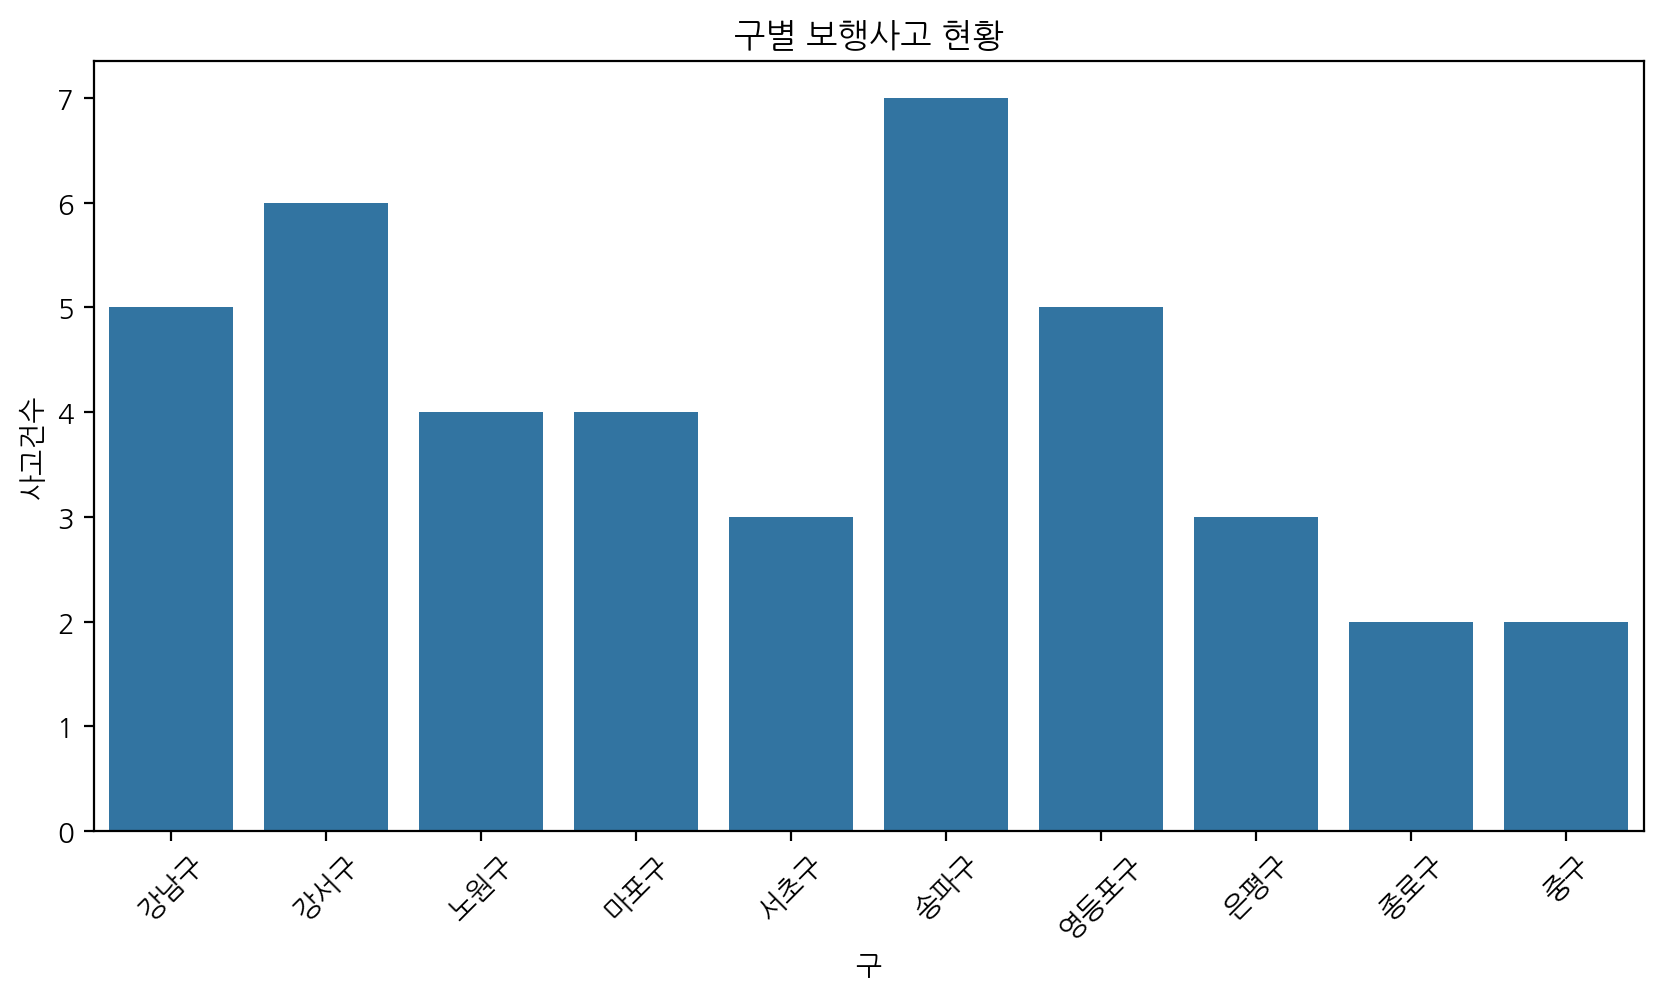

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=accident_gu.index,
    y=accident_gu.values
)

plt.title('구별 보행사고 현황')

plt.xlabel('구')
plt.ylabel('사고건수')

plt.xticks(rotation=45)

plt.show()

사고 현황을 확인하기 위한 막대그래프

-> 일부 지역에서 사고가 상대적으로 많이 발생하는 모습 확인 가능

## 5. 선그래프, 시간대별 사고 흐름 분석



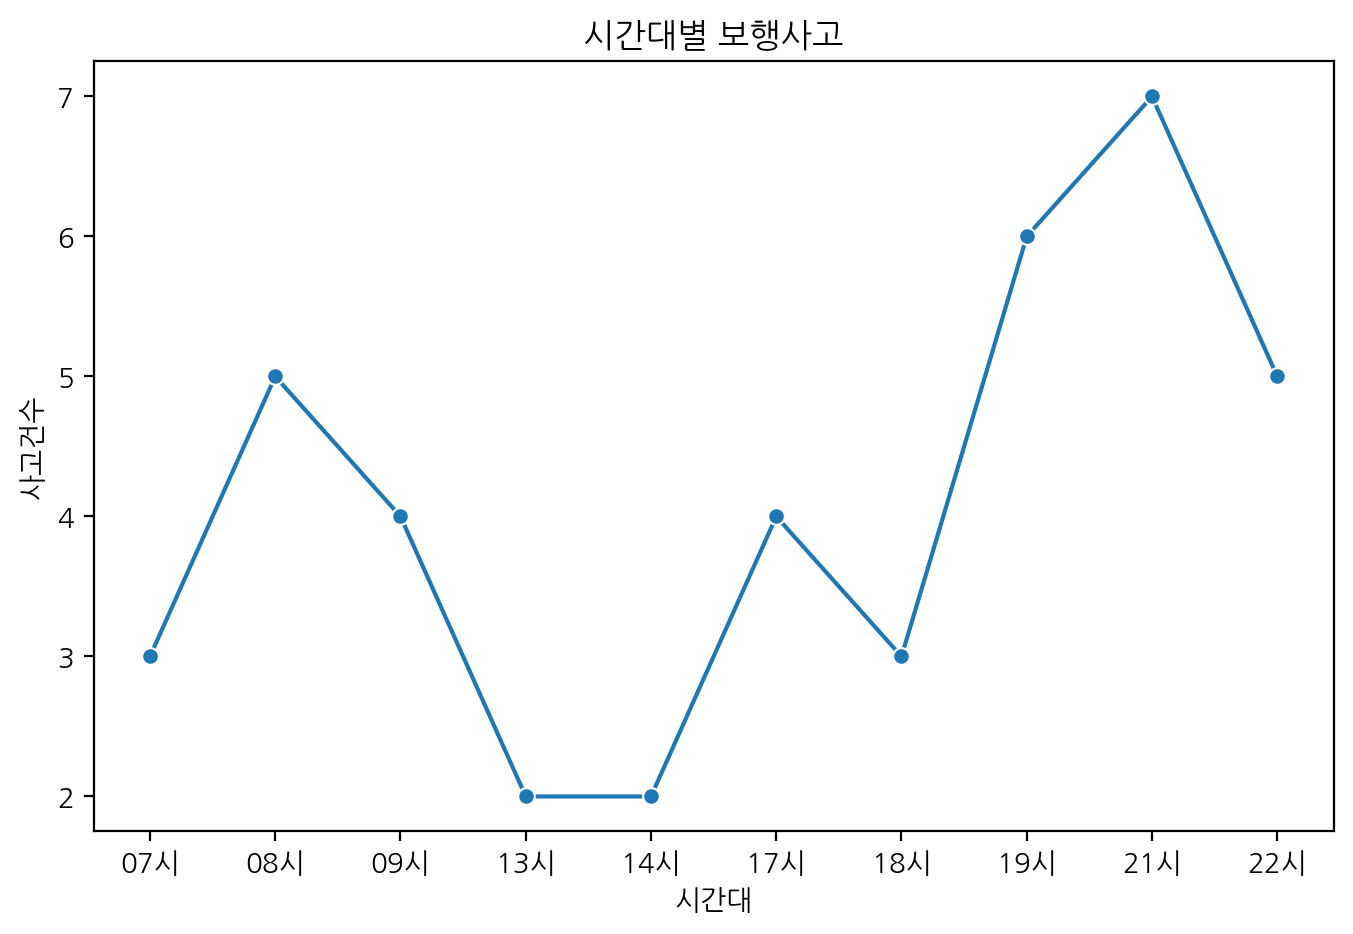

In [ ]:
time_accident = accident.groupby('시간대')['사고건수'].sum()

plt.figure(figsize=(8,5))

sns.lineplot(
    x=time_accident.index,
    y=time_accident.values,
    marker='o'
)

plt.title('시간대별 보행사고')

plt.xlabel('시간대')
plt.ylabel('사고건수')

plt.show()

특히 저녁과 야간 시간대에서 사고가 증가하는 경향 확인 가능

-> 이는 시야 확보 문제, 위험 보행 행동 증가와 연결될 가능성이 있음을 추정

## 6. regplot, 환경 요소와 사고 관계

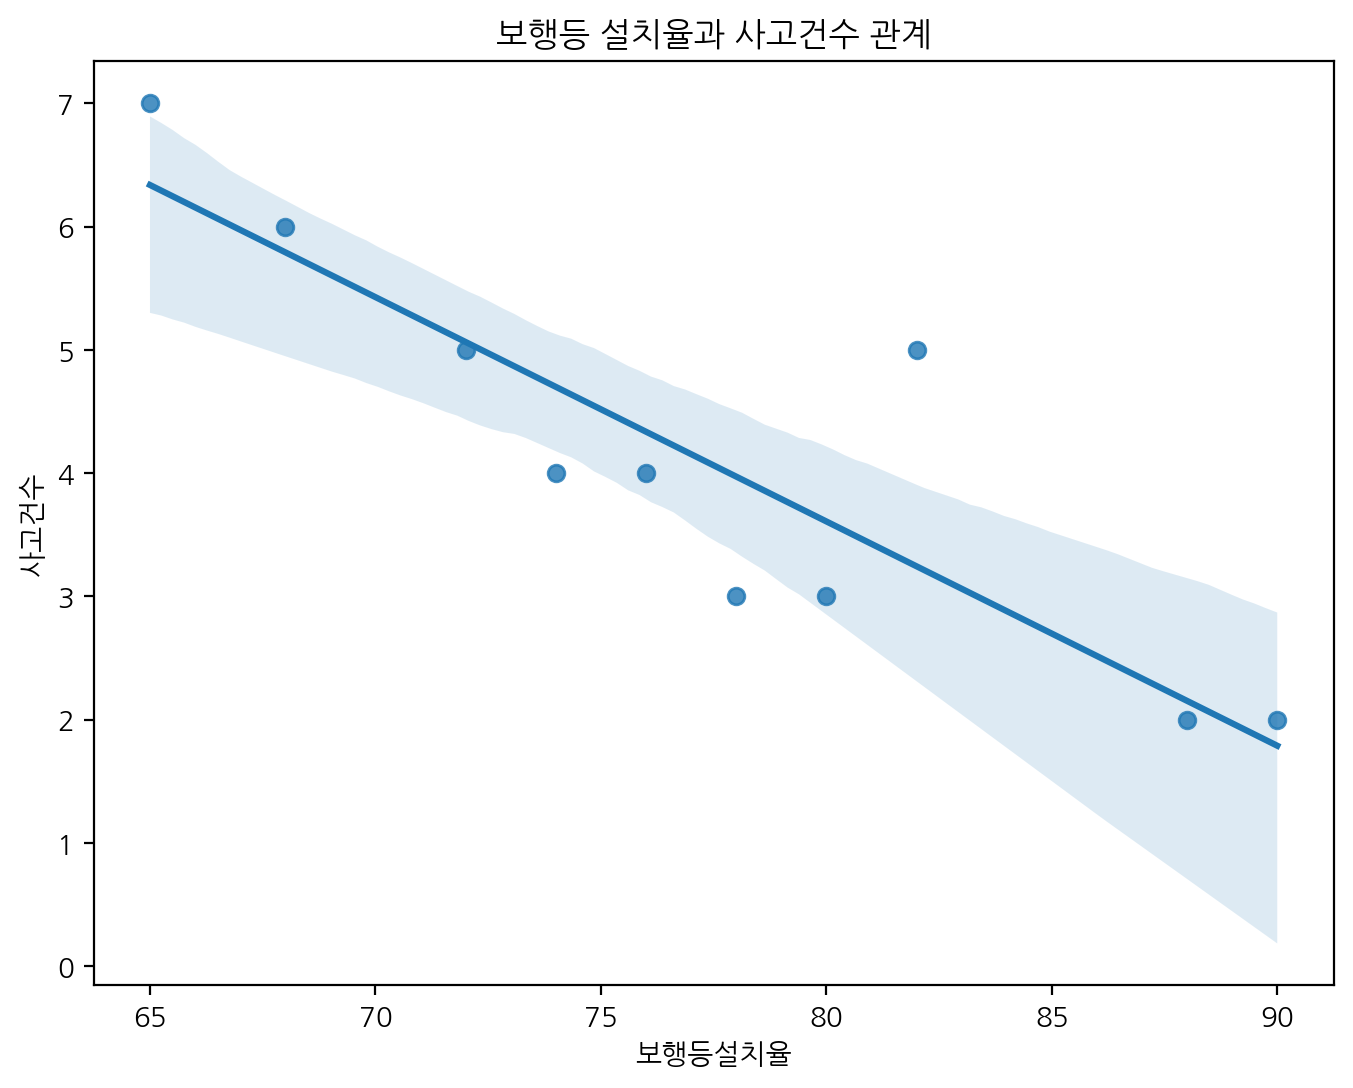

In [ ]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=accident,
    x='보행등설치율',
    y='사고건수'
)

plt.title('보행등 설치율과 사고건수 관계')
plt.show()

보행등 설치율과 사고건수의 관계 분석을 위해 회귀 그래프 사용

-> 보행 환경이 부족한 지역일수록 사고 위험 증가 가능성 확인

## 7. scatterplot, 안전점수와 사고 비교

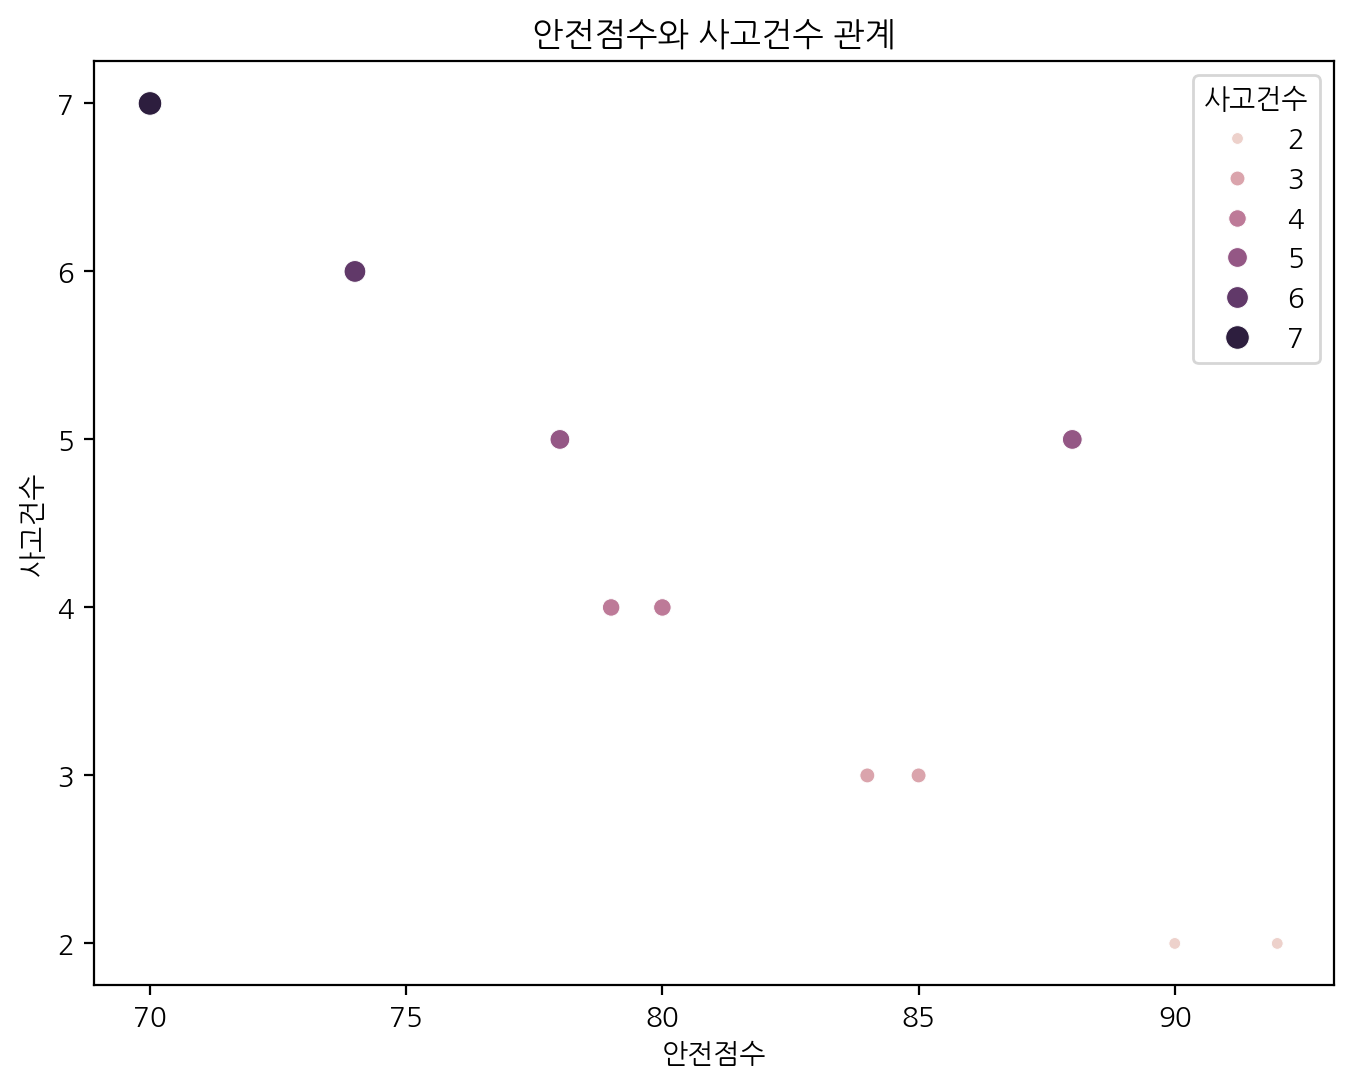

In [ ]:
plt.figure(figsize=(8,6))

#점의 크기와 색상으로 사고 규모 표현 가능
sns.scatterplot(
    data=accident,
    x='안전점수',
    y='사고건수',
    size='사고건수',
    hue='사고건수'
)

plt.title('안전점수와 사고건수 관계')

plt.show()

안전점수와 사고건수 관계를 산점도로 시각화

-> 안전점수가 낮을수록 사고가 증가하는 경향 확인

## 8. 히트맵, 변수 간 상관관계 분석

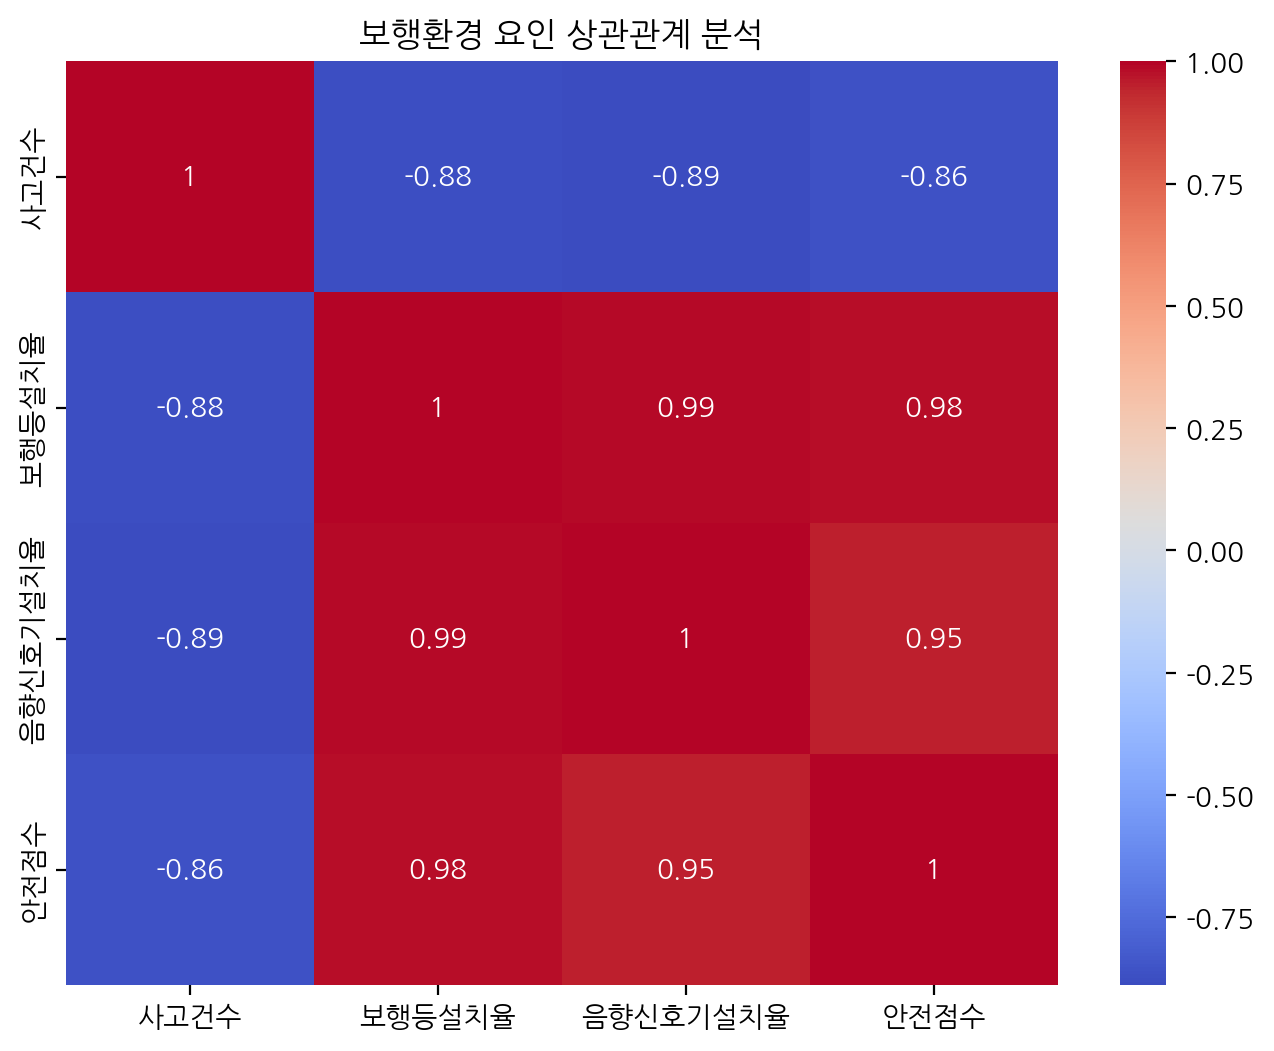

In [ ]:
corr = accident[[
    '사고건수',
    '보행등설치율',
    '음향신호기설치율',
    '안전점수'
]].corr()

#색이 진할수록 변수 간 관계가 강함

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('보행환경 요인 상관관계 분석')

plt.show()

보행등 설치율과 안전점수는 사고건수와 일정한 관계를 보임

-> 보행 환경 개선이 사고 감소와 연결될 가능성이 있음

## 9. boxplot, 이상치 탐색

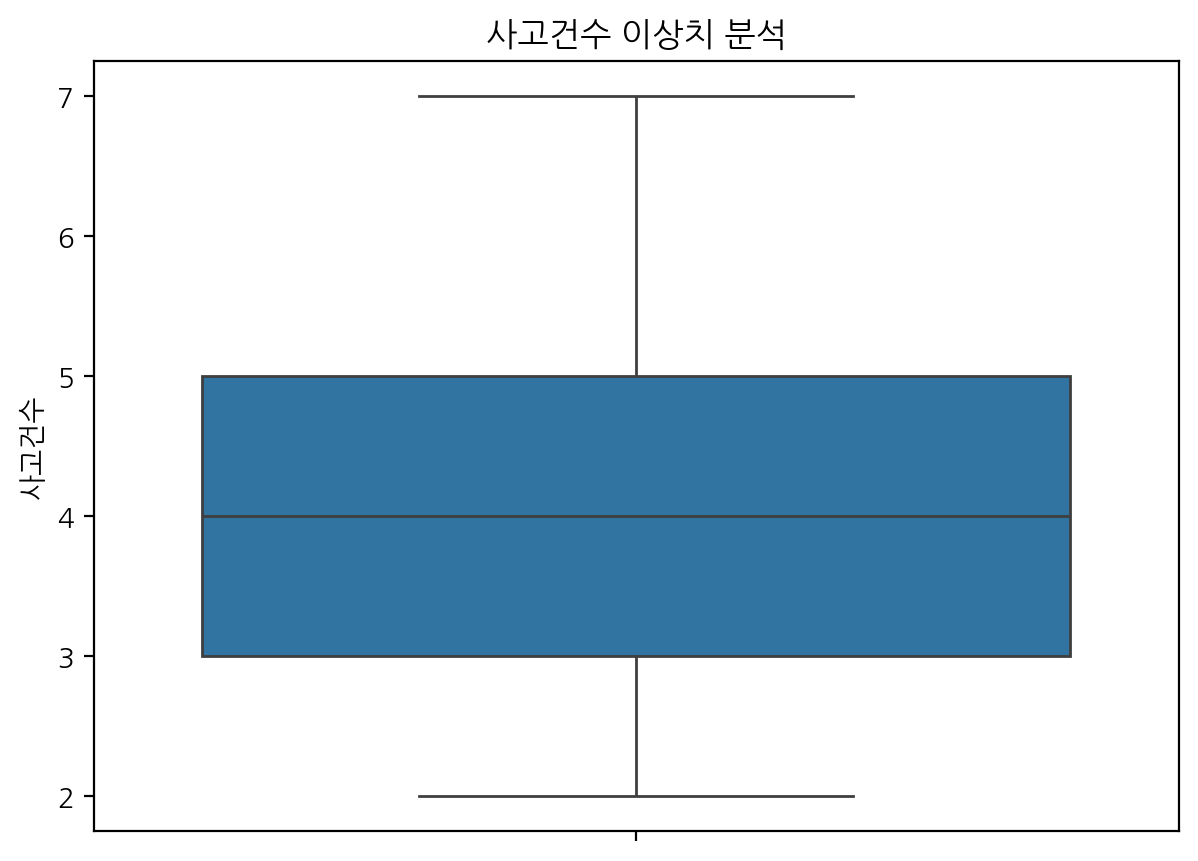

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=accident,
    y='사고건수'
)

plt.title('사고건수 이상치 분석')

plt.show()

일부 지역에서 상대적으로 높은 사고 수치가 나타나는 것을 확인할 수 있음

## 10. folium 지도, 실제 위치 시각화

In [ ]:
# 사고 위치를 지도 기반으로 시각화 한것
m = folium.Map(
    location=[37.55,126.98],
    zoom_start=11
)

for i in range(len(accident)):

    folium.CircleMarker(
        location=[
            accident.iloc[i]['위도'],
            accident.iloc[i]['경도']
        ],
        radius=int(accident.iloc[i]['사고건수']) * 2,
        color='red',
        fill=True,
        popup=accident.iloc[i]['구']
    ).add_to(m)

m

특정 지역에 사고가 집중되는 현상을 직관적으로 확인 가능

-> 사고건수가 많을수록 원 크기가 커짐